In [11]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [12]:
print(os.listdir('/kaggle/input/datasets'))

['sartajbhuvaji']


In [13]:
print(os.listdir('/kaggle/input/datasets/sartajbhuvaji'))

['brain-tumor-classification-mri']


In [14]:
print(os.listdir('/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri'))

['Training', 'Testing']


In [15]:
dataset_path_brain = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"

In [16]:
print(os.listdir(dataset_path_brain))

['no_tumor', 'pituitary_tumor', 'meningioma_tumor', 'glioma_tumor']


In [17]:
categories_brain = [
    "no_tumor",
    "pituitary_tumor",
    "meningioma_tumor",
    "glioma_tumor"
]

In [18]:
print(dataset_path_brain)

print(os.listdir(dataset_path_brain))

/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training
['no_tumor', 'pituitary_tumor', 'meningioma_tumor', 'glioma_tumor']


In [19]:
test_path = os.path.join(dataset_path_brain, "glioma_tumor")

print(test_path)

print(len(os.listdir(test_path)))

/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/glioma_tumor
826


In [20]:
import cv2
import numpy as np
IMG_SIZE = 64

X_brain = []
y_brain = []

for category in categories_brain:

    path = os.path.join(dataset_path_brain, category)

    print("Processing:", path)

    label = categories_brain.index(category)

    for img_name in os.listdir(path):

        img_path = os.path.join(path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:

            print("Failed:", img_path)

            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X_brain.append(img.flatten())

        y_brain.append(label)

print("DONE")


Processing: /kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/no_tumor
Processing: /kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/pituitary_tumor
Processing: /kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/meningioma_tumor
Processing: /kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/glioma_tumor
DONE


In [21]:
X_brain = np.array(X_brain)
y_brain = np.array(y_brain)

print(X_brain.shape)
print(y_brain.shape)

(2870, 4096)
(2870,)


In [22]:
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

In [23]:
X_train_brain, X_test_brain, y_train_brain, y_test_brain = train_test_split(
    X_brain,
    y_brain,
    test_size=0.2,
    random_state=42,
    stratify=y_brain
)

print(X_train_brain.shape)
print(X_test_brain.shape)

(2296, 4096)
(574, 4096)


In [24]:
model_brain = XGBClassifier()

model_brain.fit(X_train_brain, y_train_brain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
y_pred_brain = model_brain.predict(X_test_brain)

In [26]:
acc_brain = accuracy_score(y_test_brain, y_pred_brain)

print("Brain Tumor XGBoost Accuracy:", acc_brain)

Brain Tumor XGBoost Accuracy: 0.89198606271777


In [27]:
print(classification_report(y_test_brain, y_pred_brain))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89        79
           1       0.94      0.96      0.95       166
           2       0.82      0.82      0.82       164
           3       0.95      0.87      0.91       165

    accuracy                           0.89       574
   macro avg       0.89      0.90      0.89       574
weighted avg       0.89      0.89      0.89       574



In [28]:
from sklearn.decomposition import PCA

In [29]:
pca_brain = PCA(n_components=100)

In [30]:
X_train_brain_pca = pca_brain.fit_transform(X_train_brain)

X_test_brain_pca = pca_brain.transform(X_test_brain)

In [31]:
print(X_train_brain_pca.shape)
print(X_test_brain_pca.shape)

(2296, 100)
(574, 100)


In [32]:
model_brain_pca = XGBClassifier()

model_brain_pca.fit(X_train_brain_pca, y_train_brain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [33]:
y_pred_brain_pca = model_brain_pca.predict(X_test_brain_pca)

In [34]:
acc_brain_pca = accuracy_score(y_test_brain, y_pred_brain_pca)

print("Brain Tumor PCA + XGBoost Accuracy:", acc_brain_pca)

Brain Tumor PCA + XGBoost Accuracy: 0.8310104529616724


In [35]:
print(classification_report(y_test_brain, y_pred_brain_pca))

              precision    recall  f1-score   support

           0       0.89      0.65      0.75        79
           1       0.86      0.95      0.90       166
           2       0.82      0.73      0.77       164
           3       0.79      0.90      0.84       165

    accuracy                           0.83       574
   macro avg       0.84      0.81      0.82       574
weighted avg       0.83      0.83      0.83       574



In [36]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.preprocessing.image import img_to_array

2026-05-17 06:44:54.769361: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779000294.952933      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779000295.010057      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779000295.432931      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779000295.432965      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779000295.432968      57 computation_placer.cc:177] computation placer alr

In [37]:
vgg_brain = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

I0000 00:00:1779000314.830272      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [38]:
def extract_brain_features(folder_path, categories):

    features = []
    labels = []

    for category in categories:

        path = os.path.join(folder_path, category)

        label = categories.index(category)

        for img_name in os.listdir(path):

            try:

                img_path = os.path.join(path, img_name)

                img = cv2.imread(img_path)

                img = cv2.resize(img, (128, 128))

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                img = img_to_array(img)

                img = preprocess_input(img)

                img = np.expand_dims(img, axis=0)

                feature = vgg_brain.predict(img, verbose=0)

                feature = feature.flatten()

                features.append(feature)

                labels.append(label)

            except Exception as e:
                pass

    return np.array(features), np.array(labels)

In [39]:
X_brain_vgg, y_brain_vgg = extract_brain_features(
    dataset_path_brain,
    categories_brain
)

I0000 00:00:1779000316.992815     142 service.cc:152] XLA service 0x7e24b00065e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779000316.992843     142 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779000317.141182     142 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779000318.517965     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [40]:
print(X_brain_vgg.shape)
print(y_brain_vgg.shape)

(2870, 8192)
(2870,)


In [41]:
X_train_brain_vgg, X_test_brain_vgg, y_train_brain_vgg, y_test_brain_vgg = train_test_split(
    X_brain_vgg,
    y_brain_vgg,
    test_size=0.2,
    random_state=42,
    stratify=y_brain_vgg
)

In [42]:
model_brain_vgg = XGBClassifier()

model_brain_vgg.fit(X_train_brain_vgg, y_train_brain_vgg)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [43]:
y_pred_brain_vgg = model_brain_vgg.predict(X_test_brain_vgg)

In [44]:
acc_brain_vgg = accuracy_score(y_test_brain_vgg, y_pred_brain_vgg)

print("Brain Tumor VGG16 + XGBoost Accuracy:", acc_brain_vgg)

Brain Tumor VGG16 + XGBoost Accuracy: 0.8832752613240418


In [45]:
print(classification_report(y_test_brain_vgg, y_pred_brain_vgg))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93        79
           1       0.90      0.95      0.93       166
           2       0.83      0.79      0.81       164
           3       0.90      0.88      0.89       165

    accuracy                           0.88       574
   macro avg       0.89      0.89      0.89       574
weighted avg       0.88      0.88      0.88       574



In [46]:
percentages = [0.2, 0.4, 0.6, 0.8, 1.0]

In [47]:
raw_acc_brain = []
pca_acc_brain = []
vgg_acc_brain = []

In [48]:
for p in percentages:

    print(f"\nTraining with {int(p*100)}% data")

    # ---------------- RAW XGBOOST ----------------

    if p < 1.0:

        X_sub, _, y_sub, _ = train_test_split(
            X_train_brain,
            y_train_brain,
            train_size=p,
            random_state=42,
            stratify=y_train_brain
        )

    else:

        X_sub = X_train_brain
        y_sub = y_train_brain

    model_raw = XGBClassifier()

    model_raw.fit(X_sub, y_sub)

    y_pred_raw = model_raw.predict(X_test_brain)

    acc_raw = accuracy_score(y_test_brain, y_pred_raw)

    raw_acc_brain.append(acc_raw)

    print("Raw XGB:", acc_raw)

    # ---------------- PCA + XGBOOST ----------------

    if p < 1.0:

        X_sub_pca, _, y_sub_pca, _ = train_test_split(
            X_train_brain_pca,
            y_train_brain,
            train_size=p,
            random_state=42,
            stratify=y_train_brain
        )

    else:

        X_sub_pca = X_train_brain_pca
        y_sub_pca = y_train_brain

    model_pca = XGBClassifier()

    model_pca.fit(X_sub_pca, y_sub_pca)

    y_pred_pca = model_pca.predict(X_test_brain_pca)

    acc_pca = accuracy_score(y_test_brain, y_pred_pca)

    pca_acc_brain.append(acc_pca)

    print("PCA + XGB:", acc_pca)

    # ---------------- VGG16 + XGBOOST ----------------

    if p < 1.0:

        X_sub_vgg, _, y_sub_vgg, _ = train_test_split(
            X_train_brain_vgg,
            y_train_brain_vgg,
            train_size=p,
            random_state=42,
            stratify=y_train_brain_vgg
        )

    else:

        X_sub_vgg = X_train_brain_vgg
        y_sub_vgg = y_train_brain_vgg

    model_vgg = XGBClassifier()

    model_vgg.fit(X_sub_vgg, y_sub_vgg)

    y_pred_vgg = model_vgg.predict(X_test_brain_vgg)

    acc_vgg = accuracy_score(y_test_brain_vgg, y_pred_vgg)

    vgg_acc_brain.append(acc_vgg)

    print("VGG16 + XGB:", acc_vgg)


Training with 20% data
Raw XGB: 0.7979094076655052
PCA + XGB: 0.7073170731707317
VGG16 + XGB: 0.7874564459930313

Training with 40% data
Raw XGB: 0.8414634146341463
PCA + XGB: 0.759581881533101
VGG16 + XGB: 0.8501742160278746

Training with 60% data
Raw XGB: 0.8588850174216028
PCA + XGB: 0.7665505226480837
VGG16 + XGB: 0.8641114982578397

Training with 80% data
Raw XGB: 0.872822299651568
PCA + XGB: 0.7996515679442509
VGG16 + XGB: 0.8745644599303136

Training with 100% data
Raw XGB: 0.89198606271777
PCA + XGB: 0.8310104529616724
VGG16 + XGB: 0.8832752613240418


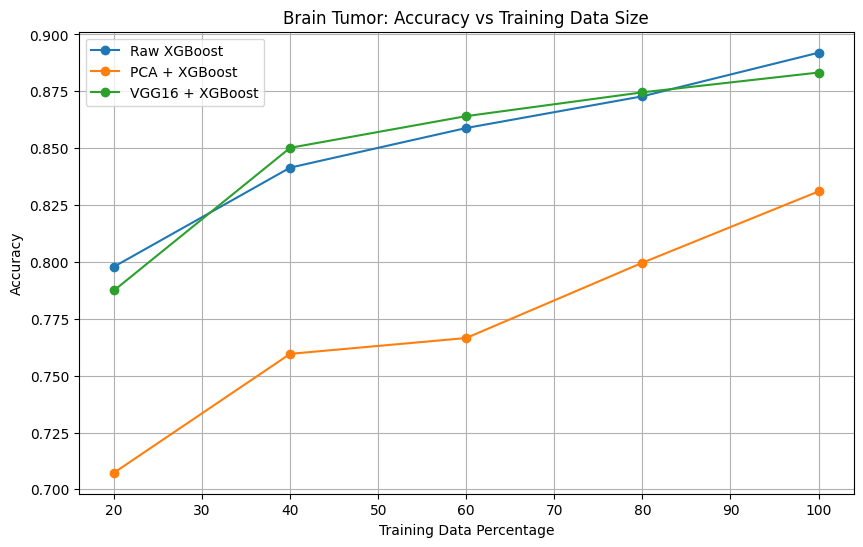

In [49]:
import matplotlib.pyplot as plt

percent_labels = [20, 40, 60, 80, 100]

plt.figure(figsize=(10,6))

plt.plot(percent_labels, raw_acc_brain, marker='o', label='Raw XGBoost')

plt.plot(percent_labels, pca_acc_brain, marker='o', label='PCA + XGBoost')

plt.plot(percent_labels, vgg_acc_brain, marker='o', label='VGG16 + XGBoost')

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("Brain Tumor: Accuracy vs Training Data Size")

plt.legend()

plt.grid(True)

plt.show()

In [50]:

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    sensitivity_list = []
    specificity_list = []

    for i in range(len(cm)):
        TP = cm[i, i]
        FN = np.sum(cm[i, :]) - TP
        FP = np.sum(cm[:, i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)

        sensitivity = TP / (TP + FN + 1e-10)
        specificity = TN / (TN + FP + 1e-10)

        sensitivity_list.append(sensitivity)
        specificity_list.append(specificity)

    sensitivity = np.mean(sensitivity_list)
    specificity = np.mean(specificity_list)

    print("Accuracy    :", round(accuracy, 4))
    print("F1 Score    :", round(f1, 4))
    print("Sensitivity :", round(sensitivity, 4))
    print("Specificity :", round(specificity, 4))

    return accuracy, f1, sensitivity, specificity


In [54]:
compute_metrics(y_test_brain, y_pred_brain)

Accuracy    : 0.892
F1 Score    : 0.8921
Sensitivity : 0.8976
Specificity : 0.9636


(0.89198606271777,
 0.8920510074400129,
 np.float64(0.8976004202043577),
 np.float64(0.9636176853174501))

In [55]:
compute_metrics(y_test_brain, y_pred_brain_pca)

Accuracy    : 0.831
F1 Score    : 0.8273
Sensitivity : 0.8065
Specificity : 0.9413


(0.8310104529616724,
 0.8272509192504697,
 np.float64(0.8065134658023286),
 np.float64(0.9413460350770263))

In [56]:
compute_metrics(y_test_brain_vgg, y_pred_brain_vgg)

Accuracy    : 0.8833
F1 Score    : 0.8824
Sensitivity : 0.89
Specificity : 0.9597


(0.8832752613240418,
 0.8823688974231149,
 np.float64(0.8899874850936312),
 np.float64(0.9596984176246501))